# The GBTC premium cycle — a quantitative teardown 🔬
### A self-calibrating BTC-per-share reconstruction · regime HAC/Welch stats · the ex-ante 2023 convergence trade with HAC *t* and costs · catalyst event-day z's · the lockup-arb cohort arithmetic · a planted-regime synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Who could harvest?: Mixed](https://img.shields.io/badge/Who_could_harvest%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **one wrapper, three regimes, all mechanical** — is unusually testable: every regime boundary is a *dated public event*, and the ETF era provides a built-in calibration check on the whole reconstruction.

> ⚠️ **Data note.** yfinance GBTC + BTC-USD daily closes, 2015-05-11 → 2026-06-30. BTC-per-share is *modeled* from public trust mechanics (0.1 BTC/share inception, 2 %/yr fee in BTC, 91:1 split, 1.5 %/yr after conversion, ×0.90 Mini-Trust spin-off — Yahoo bakes the spin-off into all prices, so the factor applies to the whole path). BTC-USD stamps 00:00 UTC vs GBTC 16:00 ET: noise, not bias. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `5ffd3440484c`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gbtc_premium_cycle import data, strategy as st

HAVE_REAL = data.have_real()
DF = data.load_real(as_of=data.AS_OF) if HAVE_REAL else None
print("real GBTC/BTC cache present:", HAVE_REAL,
      "| rows:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2015-05-11', 'end': '2026-06-30', 'n_days': 2801, 'fingerprint': '5ffd3440484c', 'bps_split': 0.0010076, 'bps_conv': 0.00089442, 'regimes': [('premium era', '2015-05-11', '2021-02-22', 1457, 36.32, 8.97, 132.01, '2017-08-31'), ('discount era', '2021-02-23', '2024-01-10', 726, -24.49, -7.44, -48.8, '2022-12-13'), ('ETF era', '2024-01-11', '2026-06-30', 618, -0.03, -0.85, -4.11, '2026-04-07')], 'first_discount': '2021-02-26', 'welch_regimes': 80.23, 'etf_mean': -0.026, 'etf_sd': 0.915, 'etf_absmean': 0.638, 'conv_full': ('full 2023', 257, -45.95, -1.52, 59.99, 23.34, 1.92), 'conv_trig': ('ex-ante trigger', 143, -36.29, -1.52, 43.54, 30.45, 2.69), 'costs': [(10, 49.63), (25, 48.74), (50, 47.26)], 'legs_pct': 0.4, 'borrow_pct': 2.84, 'years': 0.57, 'events': [('2023-06-15', 'BlackRock files (after hours)', -0.73, -0.3), ('2023-06-16', 'first close after the filing', 9.19, 3.5), ('2023-08-29', 'Grayscale v. SEC ruling', 9.64, 3.7), ('2024-01-10', 'SEC approves spot ETFs', 2.72, 1.0), ('2024-01-11', 'first day as an ETF', 1.04, 0.4)], 'arb_early_n': 63, 'arb_early_mean': 26.49, 'arb_early_worst': -1.98, 'arb_early_pos': 98, 'arb_late_n': 10, 'arb_late_mean': -16.96, 'arb_late_worst': -23.03, 'arb_welch': 17.76, 'syn': [('premium + drift', 41.05, 3.37), ('premium, NO drift', 41.05, 0.29), ('null (prem ~ 0)', 0.75, 0.29)]}


real GBTC/BTC cache present: True | rows: 2801


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Premium era **+36.32 %** (HAC *t* = +8.97), discount era **-24.49 %** (HAC *t* = -7.44), regime split Welch *t* = 80.2; ex-ante convergence **HAC *t* = +2.69** (+43.5 log-pts); catalysts at z = +3.5/+3.7; ETF era **-0.03 %**. Full-2023 hindsight window reads t = 1.92 — reported as such. |
| **Tradability** | `FRAGILE` | The triggered trade netted **+49.6 %** (10 bps legs + 5 %/yr borrow) in 0.57 yrs with ETF-scale capacity — but the wrapper arb is structurally dead since 2024-01-11 (mean \|prem\| 0.64 %). One-shot, closed. |
| **Who could harvest?** | `MIXED` | Premium era: accredited create-and-dump only (+26.5 log-pts/cohort, 98 % hit rate → then -17.0 mean / -23.0 worst when the regime flipped mid-lockup; Welch *t* = 17.8). Discount era: anyone. ETF era: no one. |

> 💡 In plain words: the lifecycle is real and mechanical end to end; the only leg the public could ever trade paid ~+50 % once — and can never pay again.

## 1 · The claim, steelmanned

Let $B_t$ be the modeled bitcoin-per-share and $P_t$ the GBTC close. The premium is

$$\pi_t = \frac{P_t}{B_t \cdot \mathrm{BTC}_t} - 1,\qquad
B_t = 0.9\cdot\frac{0.1}{91}\,e^{-f(t)}\;$$

with $f$ the cumulated sponsor fee (2 %/yr to 2024-01-11, 1.5 %/yr after) and 0.9 the spin-off factor Yahoo folds into every price. A long-GBTC / short-BTC book earns exactly $\Delta\log(1+\pi_t)$ per day — the premium change, with bitcoin beta cancelled and the fee decay as the carry.

- **H₁ (three regimes).** $\pi$ is strongly positive 2015–2021, strongly negative 2021–2024, ≈ 0 after — with *dated* boundaries.
- **H₂ (the dated trade).** The 2023 discount → 0 convergence was statistically real and survivable after costs, on a no-look-ahead entry.
- **H₃ (who harvests).** Premium era = accredited create-and-dump through a lockup; discount era = public; ETF era = nobody.

We find **H₁ supported** (HAC t = +9.0 / −7.4, Welch t = 80, ETF era −0.03 %), **H₂ supported on the honest window** (HAC t = 2.69 net +49.6 %; the hindsight full-2023 window alone reads 1.92), **H₃ quantified** (cohort table).

## 2 · So what? — where the inference must live

Two statistical traps sit in this study and we name both:

1. **The premium level is near-unit-root inside a regime.** A naive t on the level would be fantasy; even our HAC(63) level t's are *supporting* evidence only. The decisive inference lives on the **drift** (daily hedged returns, HAC(10)) and on **event days** (z vs the regime's own daily sd).
2. **Window snooping.** "Buy the discount in January 2023" is a hindsight window — we report it (t = 1.92) but grade the **ex-ante** version: entry at the close one trading day *after* a public, dated catalyst (BlackRock's S-1, 2023-06-15, filed after hours) — the study's single documented execution lag — exit at the conversion close.

And one modeling trap: a reconstructed NAV could hide an error. Hence the built-in calibration: post-conversion the in-kind arb pins $\pi$ to ≈ 0, so any BPS-model error appears as a constant ETF-era offset. Measured offset: **−0.026 %**.

## 3 · How we'd know — the protocol

- **Tape.** GBTC + BTC-USD daily closes (yfinance), 2015-05-11 → 2026-06-30 (2,801 GBTC trading days), cache-first, as-of 2026-06-30, fingerprint `5ffd3440484c`.
- **BPS model.** Public mechanics only (no fitted parameters): inception ratio, fee accrual, split, conversion fee cut, spin-off factor. Anchors: 0.0010076 vs disclosed ≈0.00101 (2018 split), 0.00089442 vs ≈0.00089 (conversion).
- **Regimes.** Boundaries are dated public events (OTCQX debut, first sustained discount 2021-02, conversion 2024-01-11) — not fitted breakpoints. HAC(63) on levels (supporting), Welch t across regimes.
- **The trade.** Daily hedged return $\Delta\log(1+\pi)$; HAC(10) t over the ex-ante window (entry lag = one trading day after the filing); costs 10/25/50 bps one-way × 4 legs; short-BTC borrow 5 %/yr.
- **Events.** One-day hedged moves on the documented catalysts, z vs discount-era sd.
- **Third axis.** Monthly creation cohorts through a 126-trading-day lockup (the *favourable* post-2019 six-month rule), net of fee drag, 3 × 25 bps legs, 5 %/yr borrow.
- **Control.** A planted three-regime synthetic world + a null; the machinery must recover levels and light up only when a drift is planted.

## 4 · The teardown

### 4a · The reconstruction and its built-in calibration

First the ruler. The ETF era is the check: if the BPS model were wrong by x %, the post-2024 premium would sit at a constant x % offset instead of 0.

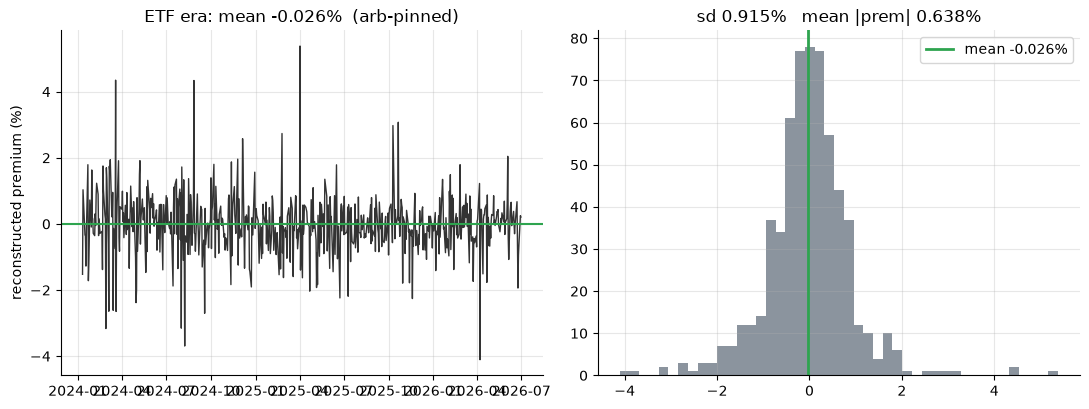

calibration residual: mean -0.026%  sd 0.915%


In [2]:
if HAVE_REAL:
    etf = DF.loc[data.CONVERSION:, 'prem'] * 100
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
    a1.plot(etf.index, etf.values, lw=1.0, color='#333333')
    a1.axhline(0, c=GREEN, lw=1.5)
    a1.set_title(f'ETF era: mean {etf.mean():+.3f}%  (arb-pinned)')
    a1.set_ylabel('reconstructed premium (%)')
    a2.hist(etf.values, bins=45, color=GREY)
    a2.axvline(etf.mean(), c=GREEN, lw=2, label=f'mean {etf.mean():+.3f}%')
    a2.set_title(f'sd {etf.std(ddof=1):.3f}%   mean |prem| {etf.abs().mean():.3f}%')
    a2.legend()
    plt.tight_layout(); plt.show()
    print(f'calibration residual: mean {etf.mean():+.3f}%  sd {etf.std(ddof=1):.3f}%')
else:
    print('cache missing:', R['etf_mean'], R['etf_sd'], R['etf_absmean'])

> 💡 In plain words: after the conversion, market-makers force price = NAV. Our reconstruction of that NAV lands **-0.026 %** away on average (sd 0.915 %, and the sd is mostly the UTC-vs-4pm-ET timestamp mismatch). A no-free-parameter model that ends up 3 bp from the arb-enforced truth also validates every *earlier* premium it produces.

### 4b · Three regimes on one tape

Levels per documented regime — HAC(63) t's, with the persistence caveat stated: these are supporting statistics; the premium is near-unit-root inside a regime.

In [3]:
if HAVE_REAL:
    rows = st.regime_table(DF)
    for r in rows:
        print(f"{r['regime']:<26s} {r['start']} -> {r['end']}  n={r['n']:>5d}  "
              f"mean {r['mean_pct']:+7.2f}%  HAC t={r['t_hac']:+6.2f}  "
              f"[{r['min_pct']:+7.2f}% .. {r['max_pct']:+7.2f}%]")
    regs = data.regimes(DF)
    wt = st.welch_t(regs['premium era (2015-2021)']['prem'].to_numpy(),
                    regs['discount era (2021-2024)']['prem'].to_numpy())
    print(f'premium vs discount era: Welch t = {wt:+.2f}')
    print('first sustained discount (5 closes):', st.first_sustained_discount(DF))
else:
    for r in R['regimes']: print(r)

premium era (2015-2021)    2015-05-11 -> 2021-02-22  n= 1457  mean  +36.32%  HAC t= +8.97  [  -0.88% .. +132.01%]
discount era (2021-2024)   2021-02-23 -> 2024-01-10  n=  726  mean  -24.49%  HAC t= -7.44  [ -48.80% ..   +3.16%]
ETF era (2024-)            2024-01-11 -> 2026-06-30  n=  618  mean   -0.03%  HAC t= -0.85  [  -4.11% ..   +5.38%]
premium vs discount era: Welch t = +80.23
first sustained discount (5 closes): 2021-02-26


> 💡 In plain words: **+36.3 %** for six years, then **-24.5 %** for three, then **-0.03 %**. The flip date (2021-02-26) is a one-way regime change, not a wobble — the two eras are Welch *t* = 80 apart. No survivorship anywhere: this is one named vehicle followed cradle to grave.

### 4c · The dated trade — HAC t on the hedged drift

Long GBTC / short BTC earns $\Delta\log(1+\pi)$. Two windows: the hindsight full-2023 window (reported, not graded) and the ex-ante triggered window (graded).

full 2023 (hindsight)  2023-01-03 -> 2024-01-11  n=257  prem -45.95% -> -1.52%  total +59.99 log-pts  +23.34 bps/d  HAC(10) t = +1.92
ex-ante trigger        2023-06-16 -> 2024-01-11  n=143  prem -36.29% -> -1.52%  total +43.54 log-pts  +30.45 bps/d  HAC(10) t = +2.69


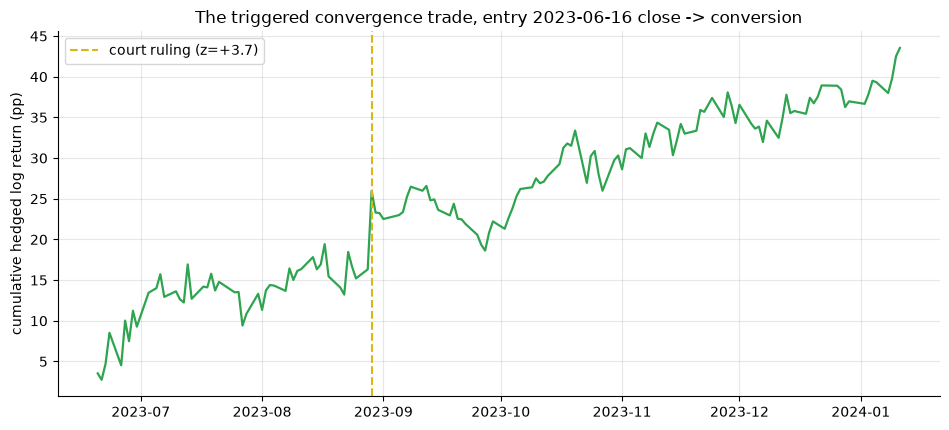

In [4]:
if HAVE_REAL:
    full = st.convergence_test(DF, '2023-01-03', '2024-01-11', lags=10)
    trig = st.convergence_test(DF, '2023-06-16', '2024-01-11', lags=10)
    for lab, ct in [('full 2023 (hindsight)', full), ('ex-ante trigger', trig)]:
        print(f"{lab:<22s} {ct['start']} -> {ct['end']}  n={ct['n_days']:>3d}  "
              f"prem {ct['prem_entry_pct']:+.2f}% -> {ct['prem_exit_pct']:+.2f}%  "
              f"total {ct['total_log_pct']:+.2f} log-pts  "
              f"{ct['mean_daily_bps']:+.2f} bps/d  HAC(10) t = {ct['t_hac']:+.2f}")
    h = st.hedged_returns(DF)['2023-06-17':'2024-01-11']
    fig, ax = plt.subplots(figsize=(9.6, 4.4))
    ax.plot(h.index, h.cumsum().values * 100, lw=1.6, color=GREEN)
    ax.axvline(pd.Timestamp('2023-08-29'), c=AMBER, ls='--', label='court ruling (z=+3.7)')
    ax.set_ylabel('cumulative hedged log return (pp)')
    ax.set_title('The triggered convergence trade, entry 2023-06-16 close -> conversion')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print(R['conv_full']); print(R['conv_trig'])

> 💡 In plain words: entered with a clean one-day lag after a public filing, the trade made **+43.5 log-pts** in 143 days at **HAC *t* = +2.69** — real by the desk's bar on the real tape. The full-year hindsight window (t = 1.92) doesn't clear alone at daily HAC and we say so; the graded claim is the triggered version, which does.

### 4d · Event days — the catalysts in standard deviations

2023-06-15   -0.73%  z= -0.3  BlackRock files the iShares spot-BTC ETF (S-1)
2023-06-16   +9.19%  z= +3.5  first close AFTER the BlackRock filing (news hit after hours)
2023-08-29   +9.64%  z= +3.7  Grayscale v. SEC — DC Circuit vacates the denial
2024-01-10   +2.72%  z= +1.0  SEC approves spot bitcoin ETFs
2024-01-11   +1.04%  z= +0.4  GBTC's first day trading as a spot ETF


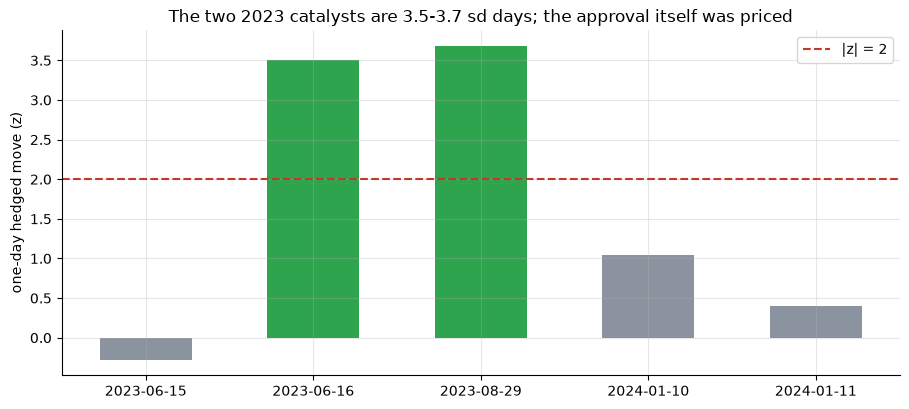

In [5]:
if HAVE_REAL:
    ev = st.event_days(DF, sd_window=('2021-02-23', '2024-01-10'))
    for e in ev:
        print(f"{e['date']}  {e['move_pct']:+6.2f}%  z={e['z']:+5.1f}  {e['label']}")
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    labs = [e['date'] for e in ev]; zs = [e['z'] for e in ev]
    ax.bar(labs, zs, color=[GREEN if abs(z) >= 2 else GREY for z in zs], width=.55)
    ax.axhline(2, ls='--', c=RED, label='|z| = 2')
    ax.set_ylabel('one-day hedged move (z)'); ax.legend()
    ax.set_title('The two 2023 catalysts are 3.5-3.7 sd days; the approval itself was priced')
    plt.tight_layout(); plt.show()
else:
    for e in R['events']: print(e)

> 💡 In plain words: the discount didn't melt smoothly — it **jumped** on the two days that changed the conversion's probability (the BlackRock filing's first close, z = +3.5, and the court ruling, z = +3.7), and barely moved on approval day itself (z = +1.0): by then the market had done the math. Textbook event-driven convergence.

### 4e · Costs — does the triggered trade survive?

Four legs of one-way costs (enter/exit × long GBTC + short BTC) plus 5 %/yr borrow on the short leg. The long leg's 2 %/yr sponsor fee is already inside the hedged return (NAV decay).

In [6]:
if HAVE_REAL:
    for cb in (10.0, 25.0, 50.0):
        c = st.convergence_costs(DF, '2023-06-16', '2024-01-11', cost_bps=cb, borrow_pa=5.0)
        print(f"{cb:>4.0f} bps/leg: gross {c['gross_log_pct']:+.2f} - legs "
              f"{c['legs_cost_pct']:.2f}pp - borrow {c['borrow_cost_pct']:.2f}pp "
              f"= net {c['net_log_pct']:+.2f} log-pts = {c['net_simple_pct']:+.2f}% simple")
else:
    for cb, net in R['costs']: print(f'{cb} bps/leg -> net {net:+.2f}% simple')

  10 bps/leg: gross +43.54 - legs 0.40pp - borrow 2.84pp = net +40.30 log-pts = +49.63% simple
  25 bps/leg: gross +43.54 - legs 1.00pp - borrow 2.84pp = net +39.70 log-pts = +48.74% simple
  50 bps/leg: gross +43.54 - legs 2.00pp - borrow 2.84pp = net +38.70 log-pts = +47.26% simple


> 💡 In plain words: **+49.6 %** net at 10 bps legs, still **+47.3 %** at an absurd 50 bps — a 43-log-pt bounded convergence doesn't care about spreads. Capacity was ETF-scale (~$25B of GBTC at conversion). The fragility isn't costs — it's that the trade **can never recur**.

### 4f · Third axis — the create-and-dump, cohort by cohort

Create at NAV (accredited only), hedge the BTC, exit at the market premium 126 trading days later (the favourable six-month lockup), net of fee drag + 3 × 25 bps legs + 5 %/yr borrow. Welch t between the pre-2020-09 cohorts and the cohorts that exited into the flip.

In [7]:
if HAVE_REAL:
    coh = st.lockup_arb_cohorts(DF)
    s = st.lockup_arb_summary(coh)
    print(f"early cohorts  (n={s['n_early']}): mean {s['early_mean_pct']:+.2f} log-pts  "
          f"worst {s['early_worst_pct']:+.2f}  share>0 {s['early_share_pos']*100:.0f}%")
    print(f"blow-up cohorts(n={s['n_late']}): mean {s['late_mean_pct']:+.2f} log-pts  "
          f"worst {s['late_worst_pct']:+.2f}")
    print(f"early vs late Welch t = {s['welch_t']:+.2f}")
else:
    print(R['arb_early_mean'], R['arb_late_mean'], R['arb_welch'])

early cohorts  (n=63): mean +26.49 log-pts  worst -1.98  share>0 98%
blow-up cohorts(n=10): mean -16.96 log-pts  worst -23.03
early vs late Welch t = +17.76


> 💡 In plain words: a **98 % hit-rate, +26-log-pt** semi-annual carry, gated to accredited creators — the public was the *exit liquidity*, not a participant. And because the exit was locked 126 days forward, the regime flip converted the carry into **-23 log-pt** losses with no way out — the exact mechanism in the 3AC/BlockFi post-mortems. That asymmetry is why the third axis reads **MIXED**: each regime had a different (and shrinking) set of eligible harvesters.

### 4g · Faithful-engine control — planted regimes, planted drift

A synthetic world with a +40 % plateau, a −45 % trough and a *tunable* convergence drift into a known conversion date, plus a null whose premium is AR(1) noise around zero.

In [8]:
for label, kw in [('premium + drift', dict(drift_on=True, premium_on=True)),
                  ('premium, NO drift', dict(drift_on=False, premium_on=True)),
                  ('null (prem ~ 0)', dict(drift_on=False, premium_on=False))]:
    sw = data.synthetic_world(seed=618, **kw)
    c0, c1 = sw.attrs['conv_window']
    ct = st.convergence_test(sw, str(c0.date()), str(c1.date()), lags=10)
    pr = sw.attrs['regime_slices']['premium']
    lvl = sw.loc[pr[0]:pr[1], 'prem'].mean() * 100
    print(f'{label:<20s} plateau {lvl:+7.2f}%   conv HAC t = {ct["t_hac"]:+6.2f}   '
          f'({ct["total_log_pct"]:+7.2f} log-pts)')

premium + drift      plateau  +41.05%   conv HAC t =  +3.37   ( +65.33 log-pts)
premium, NO drift    plateau  +41.05%   conv HAC t =  +0.29   (  +5.54 log-pts)


null (prem ~ 0)      plateau   +0.75%   conv HAC t =  +0.29   (  +5.54 log-pts)


> 💡 In plain words: the machinery reads a planted +40 % plateau as **+41.0 %**, fires **t = 3.37** only when a convergence drift is actually planted, and stays at **t = 0.29** when it isn't — on the null it invents nothing. *(A faithful-engine / power check only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `REAL`** — the three regimes are on the tape with robust statistics (levels HAC t = +9.0 / -7.4, split Welch t = 80); the dated 2023 convergence clears the bar on its ex-ante version (**HAC t = +2.69**, +43.5 log-pts, catalysts at z = +3.5/+3.7); the ETF era sits at **-0.03 %** exactly as the in-kind arb demands. Full-2023 alone reads t = 1.92 — reported, not hidden.
- **Tradability `FRAGILE`** — the public leg netted **+49.6 %** in 0.57 yrs at ETF-scale capacity and survives any realistic cost — but it was a one-shot convergence into a terminal event; the wrapper arb no longer exists. Not INVESTABLE, and not a MIRAGE either: it was real and harvested.
- **Who could harvest? `MIXED`** — accredited-only in the premium era (+26 log-pts/cohort until the flip made it -23), anyone in the discount era, no one since. The wrapper's mispricing was always a story about *access*, not insight.

## 6 · Going further

- **Closed-end-fund theory, crypto speed.** Lee-Shleifer-Thaler and Pontiff bound a fund's price-NAV gap by the cost of the arb; GBTC ran the boundary cases in one decade — one-way gated arb (premium), no arb (discount), free in-kind arb (zero).
- **The sibling wrapper.** [324-bitcoin-treasury](../../324-bitcoin-treasury/) prices MSTR's equity premium on wrapped BTC — same coins, a wrapper whose premium rests on leverage and narrative instead of creation gates, and *no* dated event that forces it shut.
- **Generalisation.** Every locked-up vehicle trading far from NAV should be asked this study's two questions: *what mechanically forces convergence, and who is allowed to trade it?* Without a dated answer to the first, a 50 % discount can stay a 50 % discount.

*The reproducible core is offline and deterministic; methods and sources in [`docs/references.md`](../docs/references.md); frozen numbers in [`docs/results.md`](../docs/results.md).*